# 02 - Baseline Model

In questo notebook vengono addestrati modelli di Machine Learning basati sulle feature strutturate del dataset.

L'obiettivo è costruire una baseline per predire la variabile `AdoptionSpeed`, cioè la velocità con cui un cane viene adottato.

Il notebook confronta due versioni di Random Forest:

1. una Random Forest iniziale;
2. una Random Forest migliorata tramite alcuni iperparametri.

Alla fine viene analizzata l'importanza delle feature utilizzate dal modello migliore.

## 1. Import delle librerie

Vengono importate le librerie necessarie per la gestione dei dati, la divisione train/test, l'addestramento del modello e la valutazione delle prestazioni.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## 2. Caricamento del dataset pulito

Il file `dogs_clean.csv` è stato creato nel notebook di EDA e contiene solo i cani, insieme alle feature aggiuntive costruite nella fase di preprocessing.

In [13]:
dogs = pd.read_csv("../data/processed/dogs_clean.csv")

print("Dimensioni dataset:", dogs.shape)
dogs.head()

Dimensioni dataset: (8132, 30)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Description,PetID,PhotoAmt,AdoptionSpeed,description_len,has_description,age_group,gender_label,fur_length_label,maturity_size_label
0,1,Brisco,1,307,0,1,2,7,0,2,...,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3,393,1,puppy,male,medium,medium
1,1,Miko,4,307,0,2,1,2,0,2,...,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2,146,1,puppy,female,short,medium
2,1,Hunter,1,307,0,1,1,0,0,2,...,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2,390,1,puppy,male,short,medium
3,1,Siu Pak & Her 6 Puppies,0,307,0,2,1,2,7,2,...,Siu Pak just give birth on 13/6/10 to 6puppies...,97aa9eeac,9.0,3,109,1,puppy,female,short,medium
4,1,Bear,2,307,0,1,1,2,7,2,...,"For serious adopter, please do sms or call for...",8b693ca84,7.0,1,68,1,puppy,male,short,medium


## 3. Definizione delle feature e del target

Come variabile target viene utilizzata `AdoptionSpeed`.

Le feature selezionate rappresentano caratteristiche strutturate del cane e dell'annuncio, come età, sesso, taglia, stato sanitario, numero di fotografie e lunghezza della descrizione.

In [14]:
features = [
    "Age",
    "Gender",
    "MaturitySize",
    "FurLength",
    "Vaccinated",
    "Dewormed",
    "Sterilized",
    "Health",
    "Quantity",
    "Fee",
    "PhotoAmt",
    "description_len",
    "has_description"
]

X = dogs[features]
y = dogs["AdoptionSpeed"]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (8132, 13)
Target: (8132,)


## 4. Suddivisione in train e test set

Il dataset viene diviso in training set e test set.

Si utilizza `stratify=y` per mantenere nel train e nel test una distribuzione simile delle classi di `AdoptionSpeed`, dato che il target è sbilanciato.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)

Train set: (6505, 13)
Test set: (1627, 13)


## 5. Random Forest baseline

Come primo modello viene utilizzata una Random Forest con 200 alberi.

La Random Forest è un modello ensemble basato su molti alberi decisionali: ogni albero produce una previsione e la classe finale viene scelta tramite voto di maggioranza.

In [16]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_base.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_pred_base = rf_base.predict(X_test)

base_accuracy = accuracy_score(y_test, y_pred_base)

print("Accuracy Random Forest baseline:", base_accuracy)
print(classification_report(y_test, y_pred_base))

Accuracy Random Forest baseline: 0.4025814382298709
              precision    recall  f1-score   support

           0       0.18      0.06      0.09        34
           1       0.32      0.24      0.28       287
           2       0.36      0.35      0.36       433
           3       0.40      0.37      0.39       390
           4       0.47      0.59      0.52       483

    accuracy                           0.40      1627
   macro avg       0.35      0.32      0.33      1627
weighted avg       0.39      0.40      0.39      1627



## 6. Random Forest migliorata

In un secondo esperimento viene utilizzata una Random Forest con alcuni parametri modificati:

- `n_estimators=500`: aumenta il numero di alberi;
- `max_depth=20`: limita la profondità degli alberi per ridurre il rischio di overfitting;
- `class_weight="balanced"`: assegna maggiore peso alle classi meno rappresentate.

In [18]:
rf_improved = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    class_weight="balanced",
    random_state=42
)

rf_improved.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [19]:
y_pred_improved = rf_improved.predict(X_test)

improved_accuracy = accuracy_score(y_test, y_pred_improved)

print("Accuracy Random Forest migliorata:", improved_accuracy)
print(classification_report(y_test, y_pred_improved))

Accuracy Random Forest migliorata: 0.4093423478795329
              precision    recall  f1-score   support

           0       0.18      0.06      0.09        34
           1       0.33      0.28      0.30       287
           2       0.36      0.34      0.35       433
           3       0.43      0.36      0.39       390
           4       0.47      0.62      0.53       483

    accuracy                           0.41      1627
   macro avg       0.35      0.33      0.33      1627
weighted avg       0.40      0.41      0.40      1627



## 7. Confronto tra i modelli tabellari

La tabella seguente confronta l'accuracy ottenuta dalla Random Forest baseline e dalla Random Forest migliorata.

In [20]:
results = pd.DataFrame({
    "Model": [
        "Random Forest baseline",
        "Random Forest improved"
    ],
    "Accuracy": [
        base_accuracy,
        improved_accuracy
    ]
})

results

,Model,Accuracy
0,Random Forest baseline,0.402581
1,Random Forest improved,0.409342


## 8. Feature importance

La Random Forest permette di stimare l'importanza relativa delle feature.

L'analisi viene effettuata sul modello migliore, cioè la Random Forest migliorata.

In [21]:
importance = pd.DataFrame({
    "feature": features,
    "importance": rf_improved.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance

,feature,importance
11,description_len,0.300232
0,Age,0.159077
10,PhotoAmt,0.153776
9,Fee,0.054715
3,FurLength,0.052511
1,Gender,0.050039
2,MaturitySize,0.049137
8,Quantity,0.043980
6,Sterilized,0.042556
4,Vaccinated,0.041837


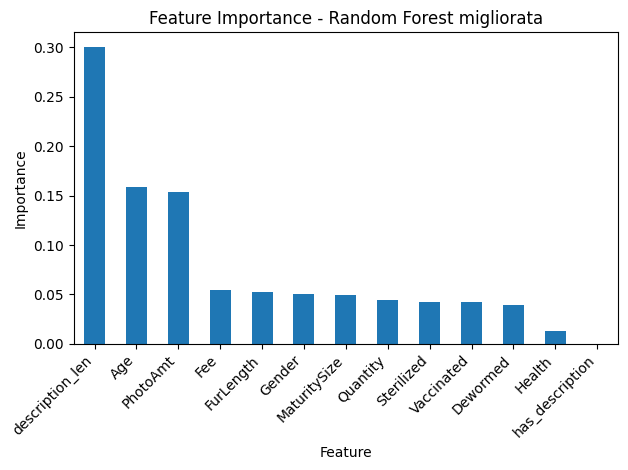

In [22]:
importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False
)

plt.title("Feature Importance - Random Forest migliorata")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Conclusioni

La Random Forest migliorata rappresenta il miglior modello tabellare tra quelli testati in questo notebook.

Nel corso degli esperimenti precedenti ha raggiunto un'accuracy di circa **40.93%**, leggermente superiore rispetto alla Random Forest iniziale.

L'analisi delle feature importance mostra che le variabili più rilevanti sono:

- lunghezza della descrizione (`description_len`);
- età del cane (`Age`);
- numero di fotografie (`PhotoAmt`);
- costo di adozione (`Fee`).

Questo risultato suggerisce che la velocità di adozione non dipende solo dalle caratteristiche fisiche del cane, ma anche dalla qualità e dalla completezza dell'annuncio.